# ESC Throughput Component Budget

This notebook shows how the ESC exposure time calculator (ETC) keeps track of every throughput element in its optical train.

- Every `add_*()` call (mirrors, filters, polarizers, the focal-plane mask, the detector QE, ...) is recorded, in order, in `obs.throughput_components`.
- `build_bandpasses()` rebuilds the three bandpasses, `bandpass`, `precoron_bandpass` and `coron_bandpass`, from that registry, so the registry is the single source of truth for them.
- `get_throughput_budget()` and `plot_throughput_budget()` only read the registry; they do not change anything.

The refactor preserves the ETC's existing numerical behaviour: the bandpasses and count rates are the same as before.

In [1]:
from stp_etc_esc import ExposureTimeSNRCalculatorESC as etsc
import astropy.units as u
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part A: a small synthetic optical train

A few flat, made-up components are enough to see how the registry and the routing flags work. This part runs in about a second and needs no configuration files.

In [2]:
obs = etsc.Observatory(
    telescope_name="Synthetic example",
    telescope_diameter=3.0 * u.m,
    telescope_focal_len=110 * u.m,
)

obs.add_generic_optic(0.95, name="primary", group="telescope")
obs.add_generic_optic(0.95, name="secondary", group="telescope")
obs.add_generic_filter(6300 * u.AA, fbw=0.02, name="filter",
                       group="instrument")
obs.add_generic_optic(0.90, name="fold_mirror", group="instrument")
# coronOnly=True also routes this optic into coron_bandpass.
obs.add_generic_optic(0.60, coronOnly=True, name="coronagraph_optic",
                      group="instrument")

len(obs.throughput_components)

5

In [3]:
registry_columns = ["name", "category", "group", "count",
                    "apply_to_bandpass", "apply_to_precoron",
                    "apply_to_coron"]

rows = []
for component in obs.throughput_components:
    rows.append({column: component[column] for column in registry_columns})

registry = pd.DataFrame(rows)
registry

,name,category,group,count,apply_to_bandpass,apply_to_precoron,apply_to_coron
0,primary,generic_optic,telescope,1,True,True,False
1,secondary,generic_optic,telescope,1,True,True,False
2,filter,generic_filter,instrument,1,True,True,False
3,fold_mirror,generic_optic,instrument,1,True,True,False
4,coronagraph_optic,generic_optic,instrument,1,True,True,True


In [4]:
budget_columns = ["name", "category", "group", "applied",
                  "throughput", "cumulative_throughput"]

for bandpass_name in ["bandpass", "precoron_bandpass", "coron_bandpass"]:
    budget = obs.get_throughput_budget(6300 * u.AA, bandpass=bandpass_name)
    print(bandpass_name)
    display(budget[budget_columns])

# Check: the last cumulative value is the bandpass itself at 6300 A.
budget = obs.get_throughput_budget(6300 * u.AA, bandpass="bandpass")
last_cumulative = budget["cumulative_throughput"].iloc[-1]
actual = obs.bandpass(6300 * u.AA).value
print("last cumulative value:", last_cumulative)
print("obs.bandpass(6300 A): ", actual)
print("equal:", np.isclose(last_cumulative, actual, rtol=1e-12, atol=0.0))

bandpass


,name,category,group,applied,throughput,cumulative_throughput
0,primary,generic_optic,telescope,True,0.95,0.950000
1,secondary,generic_optic,telescope,True,0.95,0.902500
2,filter,generic_filter,instrument,True,0.98,0.884450
3,fold_mirror,generic_optic,instrument,True,0.90,0.796005
4,coronagraph_optic,generic_optic,instrument,True,0.60,0.477603


precoron_bandpass


,name,category,group,applied,throughput,cumulative_throughput
0,primary,generic_optic,telescope,True,0.95,0.950000
1,secondary,generic_optic,telescope,True,0.95,0.902500
2,filter,generic_filter,instrument,True,0.98,0.884450
3,fold_mirror,generic_optic,instrument,True,0.90,0.796005
4,coronagraph_optic,generic_optic,instrument,True,0.60,0.477603


coron_bandpass


,name,category,group,applied,throughput,cumulative_throughput
0,primary,generic_optic,telescope,False,0.95,1.0
1,secondary,generic_optic,telescope,False,0.95,1.0
2,filter,generic_filter,instrument,False,0.98,1.0
3,fold_mirror,generic_optic,instrument,False,0.90,1.0
4,coronagraph_optic,generic_optic,instrument,True,0.60,0.6


last cumulative value: 0.47760299999999994
obs.bandpass(6300 A):  0.47760299999999994
equal: True


## Part B: the real UM configuration

The rest of the notebook uses the repository's Ultramarine (UM) configuration, built the same way as in `ESC_ExposureTimeSNRCalculator_Demo.ipynb`.

The current UM configuration is demonstrated using the pinned historical environment described in `tests/regression/README.md`. In the newer test environment, one of the existing mirror FITS files currently fails to load because its wavelength column lacks unit metadata expected by the newer synphot version. This is a data-file compatibility issue, not a limitation of the UM model.

Building the UM observatory is the slowest step in this notebook (about half a minute).

In [5]:
ESC = etsc.Observatory(
    telescope_name="Extrasolar Camera",
    telescope_diameter=3.0 * u.m,
    telescope_focal_len=110 * u.m,
)

ESC.make_STP(
    subap="A",
    plot=False,
    telconfig="UM",
    escconfig="UM",
    telpath="UM",
    escpath="UM",
    contrast="CBE",
)

len(ESC.throughput_components)

22

In [6]:
rows = []
for component in ESC.throughput_components:
    rows.append({column: component[column] for column in registry_columns})

um_registry = pd.DataFrame(rows)
um_registry

,name,category,group,count,apply_to_bandpass,apply_to_precoron,apply_to_coron
0,m1,mirror,telescope,1,True,True,False
1,m2,mirror,telescope,1,True,True,False
2,m3,mirror,telescope,1,True,True,False
3,m4,mirror,telescope,1,True,True,False
4,oap1,mirror,instrument,1,True,True,False
5,oap2,mirror,instrument,1,True,True,False
6,oap3,mirror,instrument,1,True,True,False
7,fsm,mirror,instrument,1,True,True,False
8,oap4,mirror,instrument,1,True,True,False
9,dm,mirror,instrument,1,True,True,False


## Three bandpass scopes

Each registered component carries three flags that say which bandpasses it belongs to:

- **`bandpass`**: the normal ETC throughput. `make_observation()` uses this bandpass for its count rates.
- **`precoron_bandpass`**: the components that the registry flags (`apply_to_precoron`) route into the pre-coronagraph scope.
- **`coron_bandpass`**: only the components explicitly routed into the coronagraph scope (`apply_to_coron`).

The budget tables below start from the ETC's starting bandpass at 6300 Å (the centre of the UM science filter), multiply in only the components that apply to the chosen scope, and keep every other component visible with `applied = False`.

In [7]:
budget = ESC.get_throughput_budget(6300 * u.AA, bandpass="bandpass")
budget[budget_columns]

,name,category,group,applied,throughput,cumulative_throughput
0,m1,mirror,telescope,True,0.900400,0.900400
1,m2,mirror,telescope,True,0.982036,0.884225
2,m3,mirror,telescope,True,0.982036,0.868340
3,m4,mirror,telescope,True,0.982036,0.852741
4,oap1,mirror,instrument,True,0.982036,0.837422
5,oap2,mirror,instrument,True,0.982036,0.822378
6,oap3,mirror,instrument,True,0.982036,0.807605
7,fsm,mirror,instrument,True,0.982036,0.793097
8,oap4,mirror,instrument,True,0.982036,0.778849
9,dm,mirror,instrument,True,0.909589,0.708433


In [8]:
for bandpass_name in ["precoron_bandpass", "coron_bandpass"]:
    budget = ESC.get_throughput_budget(6300 * u.AA, bandpass=bandpass_name)
    print(bandpass_name)
    display(budget[budget_columns])

precoron_bandpass


,name,category,group,applied,throughput,cumulative_throughput
0,m1,mirror,telescope,True,0.900400,0.900400
1,m2,mirror,telescope,True,0.982036,0.884225
2,m3,mirror,telescope,True,0.982036,0.868340
3,m4,mirror,telescope,True,0.982036,0.852741
4,oap1,mirror,instrument,True,0.982036,0.837422
5,oap2,mirror,instrument,True,0.982036,0.822378
6,oap3,mirror,instrument,True,0.982036,0.807605
7,fsm,mirror,instrument,True,0.982036,0.793097
8,oap4,mirror,instrument,True,0.982036,0.778849
9,dm,mirror,instrument,True,0.909589,0.708433


coron_bandpass


,name,category,group,applied,throughput,cumulative_throughput
0,m1,mirror,telescope,False,0.900400,1.000000
1,m2,mirror,telescope,False,0.982036,1.000000
2,m3,mirror,telescope,False,0.982036,1.000000
3,m4,mirror,telescope,False,0.982036,1.000000
4,oap1,mirror,instrument,False,0.982036,1.000000
5,oap2,mirror,instrument,False,0.982036,1.000000
6,oap3,mirror,instrument,False,0.982036,1.000000
7,fsm,mirror,instrument,False,0.982036,1.000000
8,oap4,mirror,instrument,False,0.982036,1.000000
9,dm,mirror,instrument,False,0.909589,1.000000


## Which components are routed differently?

Most components share one routing pattern. The next table is derived from the actual registry: it finds the most common combination of the three flags and lists every component whose routing differs from it, followed by how many registered components apply to each bandpass.

In [9]:
flag_columns = ["apply_to_bandpass", "apply_to_precoron", "apply_to_coron"]

common_routing = um_registry[flag_columns].value_counts().idxmax()
print("Most common routing (bandpass, precoron, coron):", common_routing)

differs = (um_registry[flag_columns] != list(common_routing)).any(axis=1)
display(um_registry[differs])

print("Number of registered components applied to each bandpass:")
um_registry[flag_columns].sum()

Most common routing (bandpass, precoron, coron): (True, True, False)


,name,category,group,count,apply_to_bandpass,apply_to_precoron,apply_to_coron
18,fpm,lamD_optic,instrument,1,True,False,True
21,detector_qe,sensor_qe,detector,1,True,False,False


Number of registered components applied to each bandpass:


apply_to_bandpass    22
apply_to_precoron    20
apply_to_coron        1
dtype: int64

## Part C: plots

`plot_throughput_budget()` deliberately does not add a legend. With the full UM optical train there are many curves, so each figure below adds its own legend, placed outside the axes.

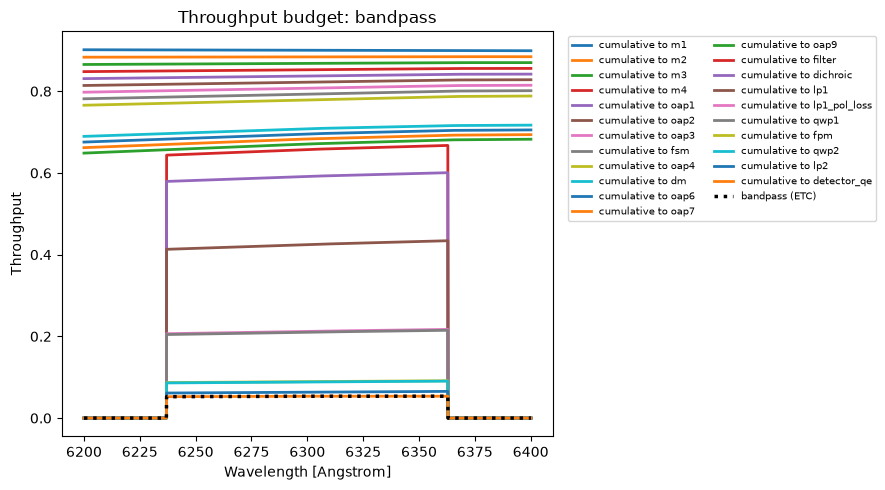

In [10]:
# Science band: running product after each applied component, and the
# actual ETC bandpass (black dotted) that the last running product matches.
wavelengths = np.arange(6200, 6400.1, 0.1) * u.AA

fig, ax = plt.subplots(figsize=(9, 5))
fig, ax, lines = ESC.plot_throughput_budget(
    wavelengths, bandpass="bandpass", show_components=False, ax=ax)
ax.legend(fontsize="x-small", ncol=2, bbox_to_anchor=(1.02, 1),
          loc="upper left")
plt.tight_layout()

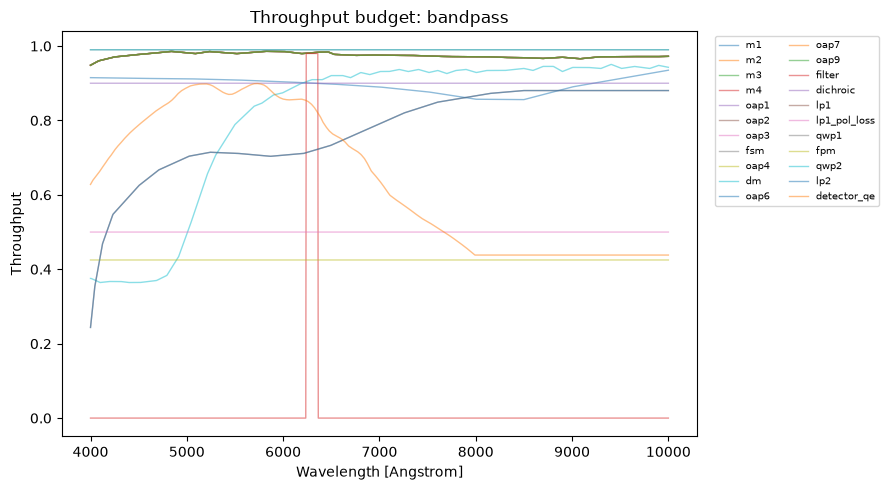

In [11]:
# Each component's own throughput over a wide range. Components with
# identical spectral shapes (for example the same coating) overlap.
wavelengths = np.arange(4000, 10001, 5) * u.AA

fig, ax = plt.subplots(figsize=(9, 5))
fig, ax, lines = ESC.plot_throughput_budget(
    wavelengths, bandpass="bandpass", show_cumulative=False,
    show_final=False, ax=ax)
ax.legend(fontsize="x-small", ncol=2, bbox_to_anchor=(1.02, 1),
          loc="upper left")
plt.tight_layout()

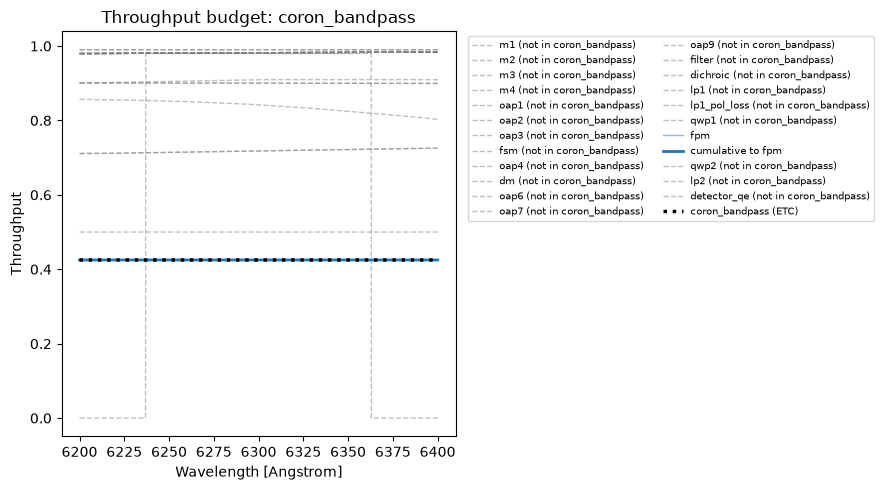

In [12]:
# Coronagraph scope over the science band. Components that are not part of
# coron_bandpass are drawn dashed grey; only the applied ones change the
# running product.
wavelengths = np.arange(6200, 6400.1, 0.1) * u.AA

fig, ax = plt.subplots(figsize=(9, 5))
fig, ax, lines = ESC.plot_throughput_budget(
    wavelengths, bandpass="coron_bandpass", show_excluded=True, ax=ax)
ax.legend(fontsize="x-small", ncol=2, bbox_to_anchor=(1.02, 1),
          loc="upper left")
plt.tight_layout()

## Part D: what the count rate includes

- `make_observation()` computes its count rates through `self.bandpass`.
- The detector QE is part of `self.bandpass`, so it is included in the normal, detector-inclusive count rate.
- With the detector QE included, the result is effectively in photoelectrons per second.
- A deliberately constructed system with the detector QE removed gives the corresponding rate in photons per second.
- `precoron_bandpass` should not be read as a general "no detector QE" photon bandpass: its routing also differs from `bandpass` in other ways (see the routing table above).

This notebook does not call `make_observation()`.

## Magnitude scaling

For the same source spectrum and the same system, the count rate scales with magnitude as

$$\frac{\mathrm{rate}(m)}{\mathrm{rate}(0)} = 10^{-0.4\,m}$$

so a source 3 magnitudes fainter gives $10^{-1.2} \approx 0.063$ of the rate, and 5 magnitudes fainter gives exactly 0.01. The Stage 5 tests check these ratios through the real `make_observation()` count-rate path, in both supported test environments.

In [13]:
magnitudes = [3, 5]
pd.DataFrame({
    "magnitude": magnitudes,
    "relative_rate": [10**(-0.4 * m) for m in magnitudes],
})

,magnitude,relative_rate
0,3,0.063096
1,5,0.010000


## Validation

The throughput refactor was checked outside this notebook (these checks are not re-run here):

- 68/68 synthetic tests pass in both supported test environments.
- The historical UM regression passes all 52 scientific comparisons.
- `bandpass`, `precoron_bandpass` and `coron_bandpass` each match the stored baseline at 577 wavelengths, with a maximum numerical difference of zero.
- 49/49 summary rows (peaks, widths, count rates, SNR, integration and saturation times) remain exact.